## Initialization

Training your neural network requires specifying an initial value of the weights. A well chosen initialization method will help learning.
But how do you choose the initialization for a new neural network? In this notebook, you will see how different initializations lead to different results.

A well chosen intialization can:
* Speed up the convergence of gradient descent
* Increase the odds of gradient descent converging to a lower training (and generalization) error.

We start by loading the necessary packages for the planar dataset we try to classify




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from init_utils import sigmoid, relu, compute_loss, forward_propagation, backward_propagation
from init_utils import update_parameters, predict, load_dataset, plot_decision_boundary, predict_dec

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0)  # setting default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams["image.cmap"] = 'gray'

train_X, train_Y, test_X, test_Y = load_dataset()

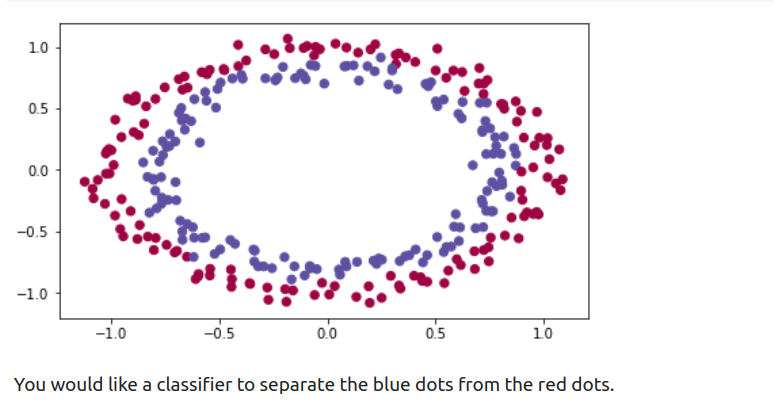

## Neural Network Model
We will use a 3-layer neural network (already implemented for you). Here are the initialization methods you will experiment with:
* zeros_initialization -- setting `initialization = "zeros"` in the input argiment
* Random initialization -- setting `initialization = "random"` in the input argument. This initialized the weights to large random values.

* He initialization - `initialization = "he"` in the input argument. This initializes the weights to random values sacled according to the paper by He et al, 2015


In [2]:
def model(X, Y, learning_rate=0.01, num_iterations=15000, print_cost=True, initialization="he"):
  """
  Implements a three-layer neural network: LINEAR->RELU->LINEAR->RELU->LINEAR->SIGMOID.

  Arguments:
  X -- input data, of shape (2, number of examples)
  Y -- true "label" vector (containing 0 for red dots; 1 for blue dots), of shape (1, number of examples)
  learning_rate -- learning rate for gradient descent
  num_iterations -- number of iterations to run gradient descent
  print_cost -- if True, print the cost every 1000 iterations
  initialization -- flag to choose which initialization to use ("zeros","random" or "he")

  Returns:
  parameters -- parameters learnt by the model
  """
  grads = {}
  costs = []
  m = X.shape[1]

  layers_dims = [X.shape[0], 10, 5, 1]

  if initialization == "zeros":
    parameters = initialize_parameters_zeros(layers_dims)
  elif initialization == 'random':
    parameters = initialize_parameters_random(layers_dims)
  elif initialization == "he":
    parameters = initialize_parameters_he(layers_dims)

  for i in range(0, num_iterations):
    a3, cache = forward_propagation(X, parameters)

    cost = compute_loss(a3, Y)
    grads = backward_propagation(X, Y, cache)

    parameters = update_parameters(parameters, grads, learning_rate)

    if print_cost and i % 1000 == 0:
       print("Cost after interation {}:{}".format(i, cost))

       costs.append(cost)

  plt.plot(costs)
  plt.ylabel('cost')
  plt.xlabel('iterations per hundereds)')
  plt.title("Learning rate= " + str(learning_rate))
  plt.show()
  return parameters










## Zero Initialization
There are two types of parameters to initialize in a neural network:

* the weight matrices $$(W^{[1]}, W^{[2]}, W^{[3]}, ..., W{[L-1]}, W^{[L]})$$
* the bias vectors $$(b^{[1]}, b^{[2]}, b^{[3]},..., b^{[L-1]}, b^{[L]})$$




We implement the fun: to initialize all parameters to zeros, but we'll see later that this does't work well since it fails to "break symmetry"


In [3]:
def initialize_parameters_zeros(layers_dims):
  """ Args:
  layer_dims -- python array (list) comtaining the size of each layer

  Returns:
  parameters: --  python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":

                      W1 -- weight matrix of shape (layers_dims[1], layers_dims[0])
                      b1 -- bias vector of shape (layers_dims[1], 1)

                      WL -- weight matrix of shape (layers_dims[L], layers_dims[L-1])
                      bL -- bias vector of shape (layers_dims[L], 1)




  """
  parameters = {}

  L = len(layers_dims)

  for l in range(1, L):
    parameters["W" + str(l)] = np.zeros((layers_dims[l], layers_dims[l - 1]))
    parameters["b" + str(l)] = np.zeros((layers_dims[l], 1))

  return parameters






In [4]:
parameters = initialize_parameters_zeros([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[0. 0. 0.]
 [0. 0. 0.]]
b1 = [[0.]
 [0.]]
W2 = [[0. 0.]]
b2 = [[0.]]




Run the following code to train your model on 15,000 iterations using zeros initialization.


Cost after interation 0:0.6931471805599453
Cost after interation 1000:0.6931471805599453
Cost after interation 2000:0.6931471805599453
Cost after interation 3000:0.6931471805599453
Cost after interation 4000:0.6931471805599453
Cost after interation 5000:0.6931471805599453
Cost after interation 6000:0.6931471805599453
Cost after interation 7000:0.6931471805599453
Cost after interation 8000:0.6931471805599453
Cost after interation 9000:0.6931471805599453
Cost after interation 10000:0.6931471805599453
Cost after interation 11000:0.6931471805599453
Cost after interation 12000:0.6931471805599453
Cost after interation 13000:0.6931471805599453
Cost after interation 14000:0.6931471805599453


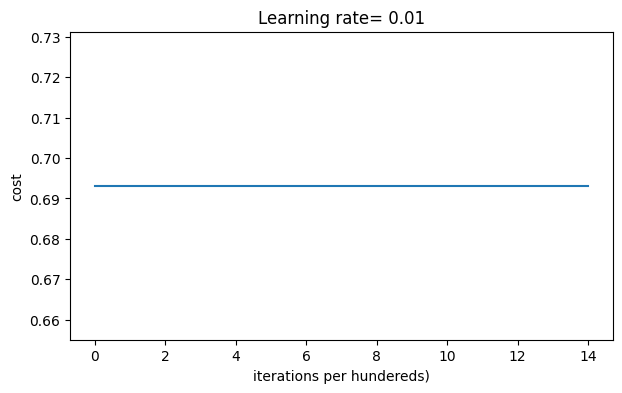

On the train set
Accuracy: 0.5
On test set
Accuracy: 0.5


In [5]:
parameters = model(train_X, train_Y, initialization='zeros')
print("On the train set")
predictions_train = predict(train_X, train_Y, parameters)
print("On test set")
predictions_test = predict(test_X, test_Y, parameters)



The performance is really bad, and the cost does not really decrease, and the algorithm performs no better than random guessing. Why? Lets look at the details of the predictions and the decision boundary:


In [6]:
print("predictions_train = " + str(predictions_train))
print("predictions_test = " + str(predictions_test))

predictions_train = [[False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False False False False False False False False False
  False False Fals

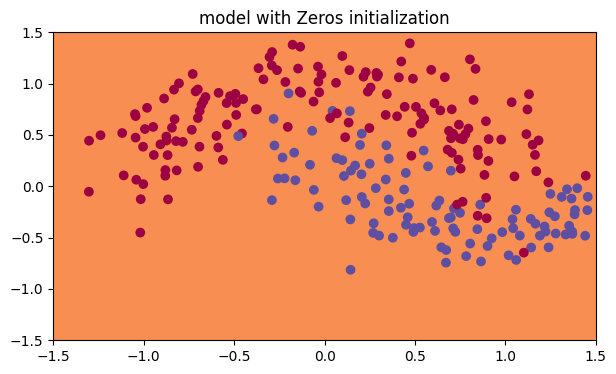

In [7]:
plt.title("model with Zeros initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)
# plot_decision_boundary(lambda x: predict_dec(parameters, x), train_X, train_Y)


The model is predicting 0 for every example.

In general, initializing all the weights to zero results in the network failing to break symmetry. This means that every neuron in each layer will learn the same thing, and you might as well be training a neural network with $$n^{[l]} =1 $$for every layer, and the network is no more powerful than a linear classifier such as logistic regression.
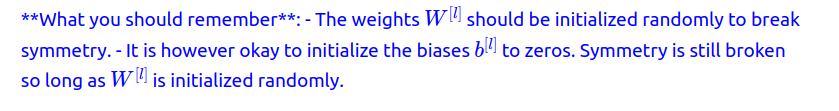

## Random initialization
 To break symmetry, lets intialize the weights randomly. Following random initialization, each neuron can then proceed to learn a different function of its inputs. Here ,we will see what happens if the weights are intialized randomly, but to very large values.


 We implement the following function to initialize your weights to large random values (scaled by *10) and your biases to zeros. Using np.random.randn(..,..) * 10 for weights and np.zeros((.., ..)) for biases. We are using a fixed np.random.seed(..) to make sure your "random" weights match ours, so don't worry if running several times your code gives you always the same initial values for the parameters.



In [10]:
def initialize_parameters_random(layers_dims):
  np.random.seed(3)
  parameters = {}
  L = len(layers_dims)

  for l in range(1, L):
    parameters["W" + str(l)] = np.random.randn(layers_dims[l], layers_dims[l - 1]) * 10
    parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
  return parameters



In [11]:
parameters = initialize_parameters_random([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[ 17.88628473   4.36509851   0.96497468]
 [-18.63492703  -2.77388203  -3.54758979]]
b1 = [[0.]
 [0.]]
W2 = [[-0.82741481 -6.27000677]]
b2 = [[0.]]




Run the following code to train your model on 15,000 iterations using random initialization.


/content/init_utils.py:86: RuntimeWarning: divide by zero encountered in log
  logprobs = np.multiply(np.log(A3), Y) + np.multiply(np.log(1 - A3), (1 - Y))
/content/init_utils.py:86: RuntimeWarning: invalid value encountered in multiply
  logprobs = np.multiply(np.log(A3), Y) + np.multiply(np.log(1 - A3), (1 - Y))


Cost after interation 0:nan
Cost after interation 1000:nan
Cost after interation 2000:nan
Cost after interation 3000:nan
Cost after interation 4000:nan
Cost after interation 5000:nan
Cost after interation 6000:nan
Cost after interation 7000:nan
Cost after interation 8000:nan
Cost after interation 9000:nan
Cost after interation 10000:nan
Cost after interation 11000:nan
Cost after interation 12000:nan
Cost after interation 13000:nan
Cost after interation 14000:nan


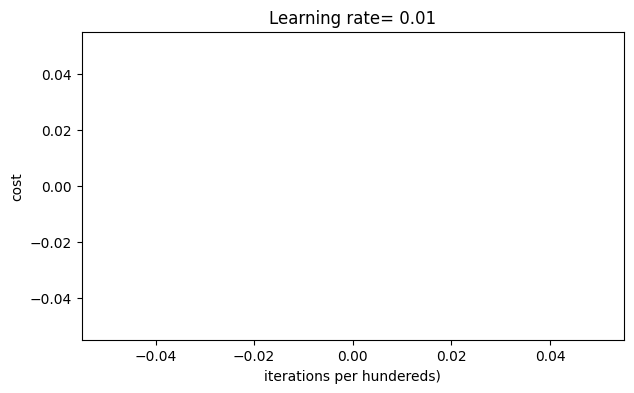

on the train set
Accuracy: 0.8266666666666667
On the test set:
Accuracy: 0.85


In [12]:
parameters = model(train_X, train_Y, initialization="random")
print("on the train set")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

If you see "inf" as the cost after the iteration 0, this is because of numerical roundoff; a more numerically sophisticated implementation would fix this. But this isn't worth worrying about for our purposes.

Anyway, it looks like you have broken symmetry, and this gives better results. than before. The model is no longer outputting all 0s.

In [13]:
print(predictions_train)
print(predictions_test)

[[False  True  True  True False False False  True False False False False
   True False False False  True  True False False False  True False False
  False  True False False  True  True  True  True False False  True  True
  False  True False False False False  True False False False False  True
  False  True False False False  True False False False False False False
  False False  True False  True False  True False False False False False
  False False False  True  True  True  True  True False False False  True
  False  True  True  True False False  True False False  True False False
   True  True False  True  True  True False  True  True False False  True
   True  True False  True  True False  True False False False False  True
  False  True False False False  True False  True False False False  True
  False False False  True False False False False  True  True False False
  False False False False False  True False False False False False  True
   True  True False  True  True False 

/content/init_utils.py:14: RuntimeWarning: overflow encountered in exp
  s = 1 / (1 + np.exp(-z))


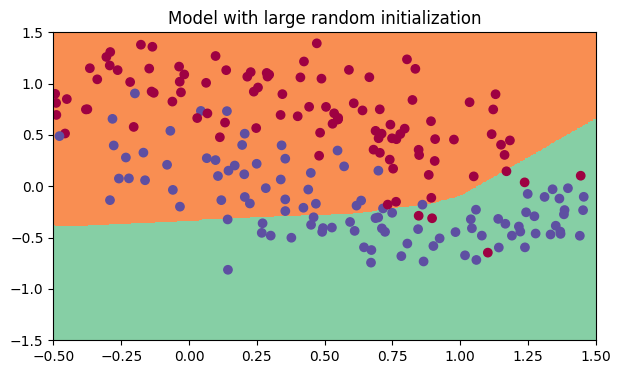

In [14]:
plt.title("Model with large random initialization")
axes = plt.gca()
axes.set_xlim([-.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

** Observations**

The cost starts very high. This is because with large random-valued weights, the last activation `(sigmoid)` outputs results that are very close to 0 or 1 for some examples, and when it gets that example wrong it incurs a very high loss for that example. Indeed, when , $$a^{[3]} = log(0), the loss goes to infinity.

* Poor initialization can lead to vanishing/exploding gradients, which also slows down the optimization algorithm
* If you train this network longer you will see better results, but initializing with overly large random numbers slows down the optimization.

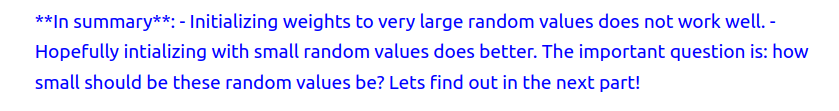

## He -Initialization

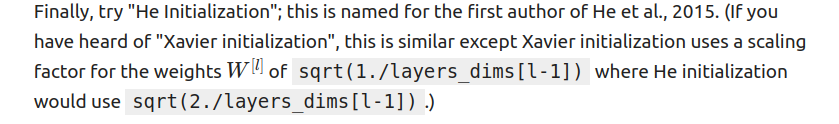

The function is similar to the previous `initialize_parameters_random(...)`
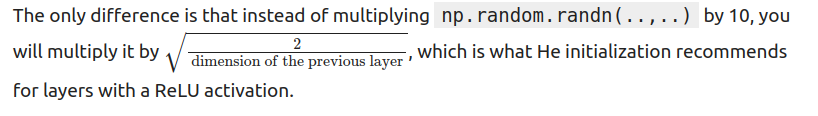

In [20]:
def initialize_parameters_he(layers_dims):
  np.random.seed(3)
  parameters = {}
  L = len(layers_dims) - 1 # integer representing the number of layers

  for l in range(1,L + 1):
    parameters["W" + str(l)] = np.random.randn(layers_dims[l], layers_dims[l - 1])* np.sqrt(2 / layers_dims[l - 1])
    # parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l - 1]) * np.sqrt(2 / layers_dims[l - 1])
    parameters['b' + str(l)]= np.zeros((layers_dims[l], 1))
  return parameters



In [21]:
parameters = initialize_parameters_he([2, 4, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[ 1.78862847  0.43650985]
 [ 0.09649747 -1.8634927 ]
 [-0.2773882  -0.35475898]
 [-0.08274148 -0.62700068]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.03098412 -0.33744411 -0.92904268  0.62552248]]
b2 = [[0.]]


the code below will run the code on 15,000 iterations using He Initialization



Cost after interation 0:0.7445378700077957
Cost after interation 1000:0.36456157758801455
Cost after interation 2000:0.3433119258721904
Cost after interation 3000:0.32743844406606876
Cost after interation 4000:0.31511890445118074
Cost after interation 5000:0.30099404487522824
Cost after interation 6000:0.2856174037951587
Cost after interation 7000:0.2701120566666641
Cost after interation 8000:0.24971899137406858
Cost after interation 9000:0.22885481037598843
Cost after interation 10000:0.20753581582783945
Cost after interation 11000:0.19026727985949632
Cost after interation 12000:0.17256665191239015
Cost after interation 13000:0.16031496842595575
Cost after interation 14000:0.15378661343533212


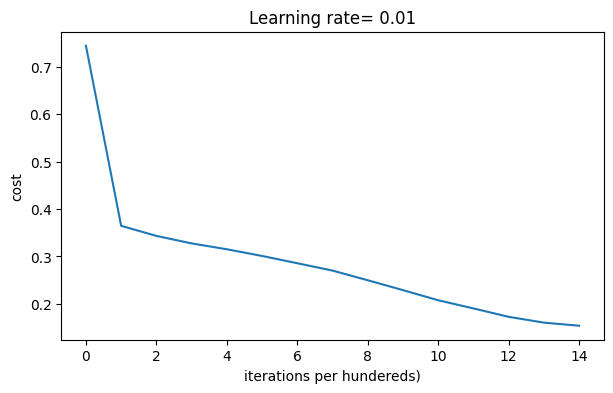

On the tain set:
Accuracy: 0.94
On the test set
Accuracy: 0.98


In [22]:
parameters = model(train_X, train_Y, initialization="he")
print("On the tain set:")
predictions_train = predict(train_X, train_Y, parameters)
print("On the test set")
predictions_test = predict(test_X, test_Y, parameters)

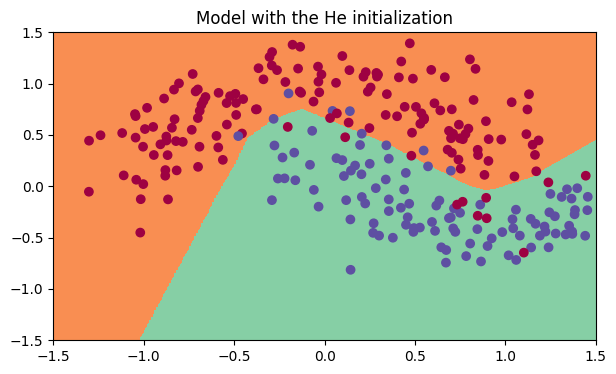

In [24]:
plt.title("Model with the He initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

*
    The model with He initialization separates the blue and the red dots very well in a small number of iterations.

### Summary
We've seent 3 different types of initializations. For the same number of iterations and same hyperparameters the comparisons are
</tr>
    <td>
    3-layer NN with zeros initialization
    </td>
    <td>
    50%
    </td>
    <td>
    fails to break symmetry
    </td>
<tr>
    <td>
    3-layer NN with large random initialization
    </td>
    <td>
    83%
    </td>
    <td>
    too large weights
    </td>
</tr>
<tr>
    <td>
    3-layer NN with He initialization
    </td>
    <td>
    99%
    </td>
      <td>
    recommended method
    </td>
</tr>

**Summary** :  Different initializations lead to different results - Random initialization is used to break symmetry and make sure different hidden units can learn different things - Don't intialize to values that are too large - He initialization works well for networks with ReLU activations.
